In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [6]:
hours = np.random.randint(low=10, high=30, size=100)
grades = 3.0 * hours + 5 + np.random.normal(0, 5.0, 100)

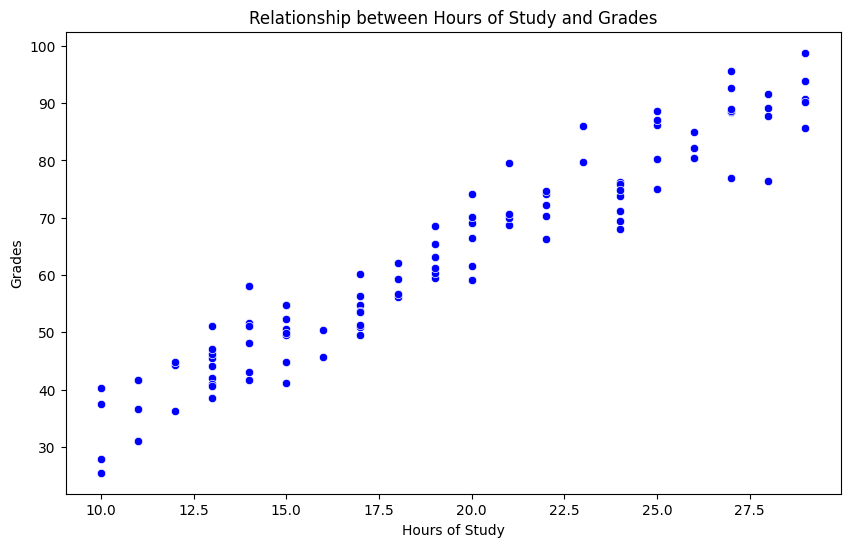

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=hours, y=grades, color='blue')
plt.xlabel('Hours of Study')
plt.ylabel('Grades')
plt.title('Relationship between Hours of Study and Grades')
plt.show()

In [8]:
X_train = hours[:80]    # 0-79
y_train = grades[:80]   # 0-79
X_test = hours[80:]     # 80-99
y_test = grades[80:]    # 80-99

In [11]:
print(X_train.shape)
print(y_train.shape)

(80,)
(80,)


In [9]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train.reshape(-1, 1), y_train)

LinearRegression()

In [13]:
print(X_train.reshape(-1, 1).shape)

(80, 1)


In [17]:
w0 = model.intercept_
w1 = model.coef_[0]
print(w0, w1)
print(f'Phương trình hồi quy: y = {w0:.2f} + {w1:.2f}*X')

4.586525056317043 3.036519679627553
Phương trình hồi quy: y = 4.59 + 3.04*X


In [19]:
y_pred = model.predict(X_test.reshape(-1, 1))
for i in range(10):
  print(f'{y_test[i]:.2f} - {y_pred[i]:.2f}')

90.73 - 92.65
36.63 - 37.99
79.65 - 74.43
63.12 - 62.28
70.58 - 68.35
90.25 - 92.65
59.34 - 59.24
46.27 - 44.06
47.13 - 44.06
49.47 - 50.13


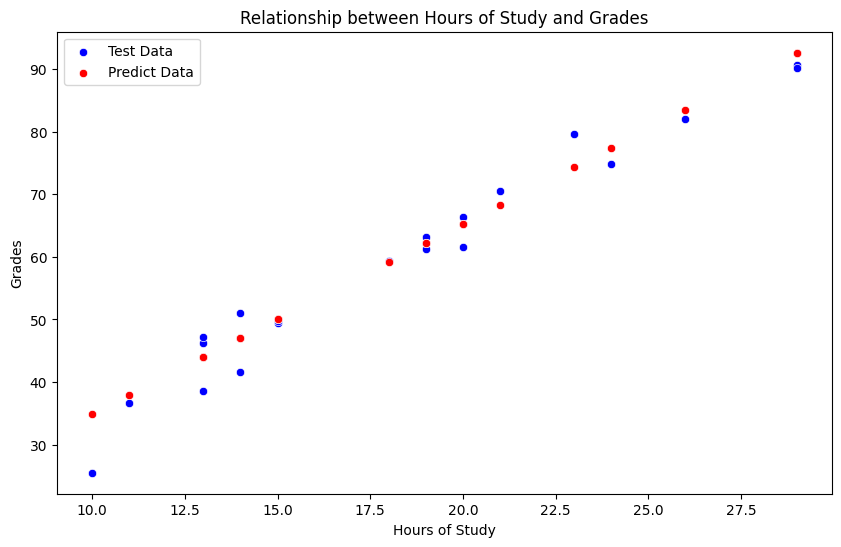

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test, y=y_test, color='blue', label='Test Data')
sns.scatterplot(x=X_test, y=y_pred, color='red', label='Predict Data')
plt.xlabel('Hours of Study')
plt.ylabel('Grades')
plt.title('Relationship between Hours of Study and Grades')
plt.show()

In [23]:
r2 = model.score(X_test.reshape(-1, 1), y_test)
print(f'R^2: {r2:.2f}')

mse = np.mean((y_test - y_pred)**2)
print(f'MSE: {mse:.2f}')

mae = np.mean(np.abs(y_test - y_pred))
print(f'MAE: {mae:.2f}')

rmse = mse ** 0.5
print(f'RMSE: {rmse:.2f}')


R^2: 0.96
MSE: 12.48
MAE: 2.73
RMSE: 3.53


In [24]:
df = pd.read_csv('data_simple_reg.csv')
df.head()

,TT,Quang_Cao,Tiep_Thi,Online,Doanh_So
0,0,12.0,5.993562,3.730133,79.732757
1,1,13.0,6.741511,3.006753,71.677897
2,2,41.0,15.405956,2.987338,175.177829
3,3,78.0,28.294987,6.934639,323.246340
4,4,11.0,6.663944,1.633811,81.594181


In [ ]:
df.isnull().sum()

In [ ]:
df.info()

In [ ]:
df.dropna(inplace=True)
df.info()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [35]:
X = df['Quang_Cao']
y = df['Doanh_So']
print(X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

(4546,) (4546,)


In [36]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3636,)
(3636,)
(910,)
(910,)


In [37]:
model = LinearRegression()
model.fit(X_train.values.reshape(-1, 1), y_train)

LinearRegression()

In [38]:
w0 = model.intercept_
w1 = model.coef_[0]
print(w0, w1)
print(f'Phương trình hồi quy: y = {w0:.2f} + {w1:.2f}*X')

43.102712740682676 3.516866955447977
Phương trình hồi quy: y = 43.10 + 3.52*X


In [42]:
y_pred = model.predict(X_test.values.reshape(-1, 1))
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R2 Score: {r2}')
print(f'MSE: {mse}')
print(f'MAE: {mae}')

R2 Score: 0.9865891440613008
MSE: 114.51607191996251
MAE: 9.1702454855096


In [45]:
X = df[['Quang_Cao', 'Tiep_Thi', 'Online']]
y = df['Doanh_So']
print(X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
model = LinearRegression()
model.fit(X_train, y_train)

(4546, 3) (4546,)


LinearRegression()

In [47]:
w0 = model.intercept_
W = model.coef_
print(W.shape)
print(f'Phương trình hồi quy: y = {w0:.2f} + {W[0]:.2f} * X1 + {W[1]:.2f} * X2 + {W[2]:.2f} * X3')

(3,)
Phương trình hồi quy: y = 42.55 + 3.39 * X1 + 0.39 * X2 + 0.03 * X3


In [49]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R2 Score: {r2}')
print(f'MSE: {mse}')
print(f'MAE: {mae}')

R2 Score: 0.9872777961051863
MSE: 108.63563242035893
MAE: 8.91644514888729


In [50]:
y_train_pred = model.predict(X_train)
r2 = r2_score(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
mae = mean_absolute_error(y_train, y_train_pred)

print(f'R2 Score: {r2}')
print(f'MSE: {mse}')
print(f'MAE: {mae}')

R2 Score: 0.98749770427375
MSE: 108.49865259734952
MAE: 8.873300522198681
